# Discussion 02: EDA and Visualizations

**Data C100 - Fall 2026**

This notebook matches the Fall 2026 Discussion 02 worksheet.


## Setup

Run these cells before starting.


In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
import sqlalchemy
import sql

%matplotlib inline
%load_ext sql
%config SqlMagic.displaylimit = 20
%config SqlMagic.style = 'DEFAULT'


In [2]:
elections = pl.read_csv("data/elections.csv")
elections.head(10)


Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
1832,"""Henry Clay""","""National Republican""",484205,"""loss""",37.603628
1832,"""William Wirt""","""Anti-Masonic""",100715,"""loss""",7.821583
1836,"""Hugh Lawson White""","""Whig""",146109,"""loss""",10.005985
1836,"""Martin Van Buren""","""Democratic""",763291,"""win""",52.272472


In [3]:
conn = duckdb.connect()
conn.execute(
    "CREATE OR REPLACE TABLE elections AS "
    "SELECT * FROM read_csv_auto('data/elections.csv')"
)


In [4]:
%sql duckdb:///:memory:


Connecting to 'duckdb:///:memory:'

In [5]:
%%sql
CREATE OR REPLACE TABLE elections AS
SELECT * FROM read_csv_auto('data/elections.csv');

SELECT * FROM elections LIMIT 10;


Running query in 'duckdb:///:memory:'

Year,Candidate,Party,Popular vote,Result,%
1824,Andrew Jackson,Democratic-Republican,151271,loss,57.21012204
1824,John Quincy Adams,Democratic-Republican,113142,win,42.78987796
1828,Andrew Jackson,Democratic,642806,win,56.20392707
1828,John Quincy Adams,National Republican,500897,loss,43.79607293
1832,Andrew Jackson,Democratic,702735,win,54.57478905
1832,Henry Clay,National Republican,484205,loss,37.6036283
1832,William Wirt,Anti-Masonic,100715,loss,7.821582644
1836,Hugh Lawson White,Whig,146109,loss,10.00598542
1836,Martin Van Buren,Democratic,763291,win,52.27247202
1836,William Henry Harrison,Whig,550816,loss,37.72154257


## EDA Practice

For each scenario, write:

1. an analysis plan that starts with **“For each…”**;
2. the corresponding Polars code; and
3. the corresponding SQL code.


### 1. Counting Election Years

How many presidential election years are included in this dataset?

#### (a) Analysis Plan

"For each unique value of `Year`, count one presidential election."

"Count the number of unique years."

The other columns do not matter because each unique `Year` represents one presidential election.

#### (b) Polars Code


In [6]:
elections["Year"].n_unique()


51

#### (c) SQL Query


In [7]:
%%sql --save query_q1
SELECT COUNT(DISTINCT Year) AS n_elections
FROM elections;


Running query in 'duckdb:///:memory:'

n_elections
51


In [8]:
query = %sqlcmd snippets query_q1
res_q1 = conn.query(query).pl()
res_q1


n_elections
i64
51


### 2. Candidate Appearances by Party

Across all elections, which parties have the most candidate appearances?

#### (a) Analysis Plan

"For each unique value of `Party`, count the number of rows."

"Sort the data in descending order of the number of rows."

The other columns do not matter because each row represents one candidate in one election.

#### (b) Polars Code


In [9]:
elections["Party"].value_counts(sort=True)

# Equivalent group-by approach:
elections.group_by("Party").len().sort("len", descending=True)


Party,len
str,u32
"""Democratic""",48
"""Republican""",42
"""Libertarian""",12
"""Prohibition""",11
"""Socialist""",10
…,…
"""Anti-Monopoly""",1
"""Dixiecrat""",1
"""Libertarian Party""",1


#### (c) SQL Query


In [10]:
%%sql --save query_q2
SELECT Party, COUNT(*) AS n_candidates
FROM elections
GROUP BY Party
ORDER BY n_candidates DESC;


Running query in 'duckdb:///:memory:'

Party,n_candidates
Democratic,48
Republican,42
Libertarian,12
Prohibition,11
Socialist,10
Green,8
Independent,7
Whig,6
Progressive,4
American Independent,3


In [11]:
query = %sqlcmd snippets query_q2
res_q2 = conn.query(query).pl()
res_q2


Party,n_candidates
str,i64
"""Democratic""",48
"""Republican""",42
"""Libertarian""",12
"""Prohibition""",11
"""Socialist""",10
…,…
"""Union Labor""",1
"""Farmer–Labor""",1
"""New Alliance""",1


### 3. Democratic Candidates in the 1900s

From 1900 through 1999, how many times did a Democrat run for president?

#### (a) Analysis Plan

"For each row, keep it if `Year` is in the 1900s and `Party` is Democratic."

"Count the number of remaining rows."

Each remaining row represents one time a Democrat ran for president.

#### (b) Polars Code


In [12]:
elections.filter(
    (pl.col("Year") >= 1900)
    & (pl.col("Year") < 2000)
    & (pl.col("Party") == "Democratic")
).height


25

#### (c) SQL Query


In [13]:
%%sql --save query_q3
SELECT COUNT(*) AS n_democrats
FROM elections
WHERE Year >= 1900
  AND Year < 2000
  AND Party = 'Democratic';


Running query in 'duckdb:///:memory:'

n_democrats
25


In [14]:
query = %sqlcmd snippets query_q3
res_q3 = conn.query(query).pl()
res_q3


n_democrats
i64
25


### 4. Parties Running Multiple Candidates

Was there ever a year when one party ran more than one candidate?

#### (a) Analysis Plan

"For each unique combination of `Year` and `Party`, count the number of rows."

"Keep only the groups where the number of rows is greater than 1."

"Check whether any groups remain."

If any groups remain, then yes, there was a year when one party ran more than one candidate.

#### (b) Polars Code


In [15]:
(
    elections.group_by(["Year", "Party"])
    .len()
    .filter(pl.col("len") > 1)
)


Year,Party,len
i64,str,u32
1824,"""Democratic-Republican""",2
1836,"""Whig""",2


#### (c) SQL Query


In [16]:
%%sql --save query_q4
SELECT Year, Party, COUNT(*) AS n_candidates
FROM elections
GROUP BY Year, Party
HAVING COUNT(*) > 1;


Running query in 'duckdb:///:memory:'

Year,Party,n_candidates
1836,Whig,2
1824,Democratic-Republican,2


In [17]:
query = %sqlcmd snippets query_q4
res_q4 = conn.query(query).pl()
res_q4


Year,Party,n_candidates
i64,str,i64
1836,"""Whig""",2
1824,"""Democratic-Republican""",2


### 5. Elections with Low-Vote Candidates

In how many elections did at least one candidate receive less than 5% of the popular vote?

#### (a) Analysis Plan

"For each unique value of `Year`, check whether at least one candidate had less than 5%."

"Count the number of years where this happened."

We count unique `Year` values, not rows, because the question asks how many elections.

#### (b) Polars Code


In [18]:
elections.filter(pl.col("%") < 5)["Year"].n_unique()


33

#### (c) SQL Query


In [19]:
%%sql --save query_q5
SELECT COUNT(DISTINCT Year) AS n_elections
FROM elections
WHERE "%" < 5;


Running query in 'duckdb:///:memory:'

n_elections
33


In [20]:
query = %sqlcmd snippets query_q5
res_q5 = conn.query(query).pl()
res_q5


n_elections
i64
33


### 6. Parties with Majority Wins

Show all rows in the elections data for parties that have received more than 50% of the vote in at least one election.

#### (a) Analysis Plan

“For each unique value of Party, check whether the largest value of `%` is greater than 50.”

“Keep only the parties where this condition is true.”

The result is a filtered `DataFrame` containing all rows for parties that have ever gotten more than 50% of the vote.

#### (b) Polars Code


In [21]:
filtered_parties = elections.filter(
    pl.col("%").max().over("Party") > 50
)
filtered_parties

Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
1836,"""Hugh Lawson White""","""Whig""",146109,"""loss""",10.005985
…,…,…,…,…,…
2016,"""Hillary Clinton""","""Democratic""",65853514,"""loss""",48.521539
2020,"""Joseph Biden""","""Democratic""",81268924,"""win""",51.311515
2020,"""Donald Trump""","""Republican""",74216154,"""loss""",46.858542


#### (c) SQL Query


In [22]:
%%sql --save query_q6
SELECT *
FROM elections
WHERE Party IN (
    SELECT Party
    FROM elections
    GROUP BY Party
    HAVING MAX("%") > 50
);


Running query in 'duckdb:///:memory:'

Year,Candidate,Party,Popular vote,Result,%
1824,Andrew Jackson,Democratic-Republican,151271,loss,57.21012204
1824,John Quincy Adams,Democratic-Republican,113142,win,42.78987796
1828,Andrew Jackson,Democratic,642806,win,56.20392707
1832,Andrew Jackson,Democratic,702735,win,54.57478905
1836,Hugh Lawson White,Whig,146109,loss,10.00598542
1836,Martin Van Buren,Democratic,763291,win,52.27247202
1836,William Henry Harrison,Whig,550816,loss,37.72154257
1840,Martin Van Buren,Democratic,1128854,loss,46.94878676
1840,William Henry Harrison,Whig,1275583,win,53.05121324
1844,Henry Clay,Whig,1300004,loss,49.250523


In [23]:
query = %sqlcmd snippets query_q6
res_q6 = conn.query(query).pl()
res_q6


Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
1836,"""Hugh Lawson White""","""Whig""",146109,"""loss""",10.005985
…,…,…,…,…,…
2016,"""Hillary Clinton""","""Democratic""",65853514,"""loss""",48.521539
2020,"""Joseph Biden""","""Democratic""",81268924,"""win""",51.311515
2020,"""Donald Trump""","""Republican""",74216154,"""loss""",46.858542


## Visualizations

Using the same dataset, sketch a visualization for each question. Then write an analysis plan and create a DataFrame that can be used to produce the visualization.


### 7. Highest Percentage per Election

What was the highest percentage of the popular vote received by any candidate during each election?

#### (a) Analysis Plan

"For each unique value of `Year`, find the largest value of `%`."

"This gives the highest popular vote percentage received by any candidate in that election."

"Create a new DataFrame with one row per election year and one column called `max_percent`."

"Sort the DataFrame in increasing order of `Year`."

"Plot `Year` against `max_percent` using a line plot."

#### (b) Polars Code


In [24]:
highest_percent_per_election = (
    elections.group_by("Year")
    .agg(max_percent=pl.col("%").max())
    .sort("Year")
)
highest_percent_per_election


Year,max_percent
i64,f64
1824,57.210122
1828,56.203927
1832,54.574789
1836,52.272472
1840,53.051213
…,…
2008,53.02351
2012,51.258484
2016,48.521539


#### (c) SQL Query


In [25]:
%%sql --save query_q7
SELECT Year, MAX("%") AS max_percent
FROM elections
GROUP BY Year
ORDER BY Year;


Running query in 'duckdb:///:memory:'

Year,max_percent
1824,57.21012204
1828,56.20392707
1832,54.57478905
1836,52.27247202
1840,53.05121324
1844,50.749477
1848,47.30929648
1852,51.01316828
1856,45.30608033
1860,39.69940846


In [26]:
query = %sqlcmd snippets query_q7
res_q7 = conn.query(query).pl()
res_q7


Year,max_percent
i64,f64
1824,57.210122
1828,56.203927
1832,54.574789
1836,52.272472
1840,53.051213
…,…
2008,53.02351
2012,51.258484
2016,48.521539


#### Visualization


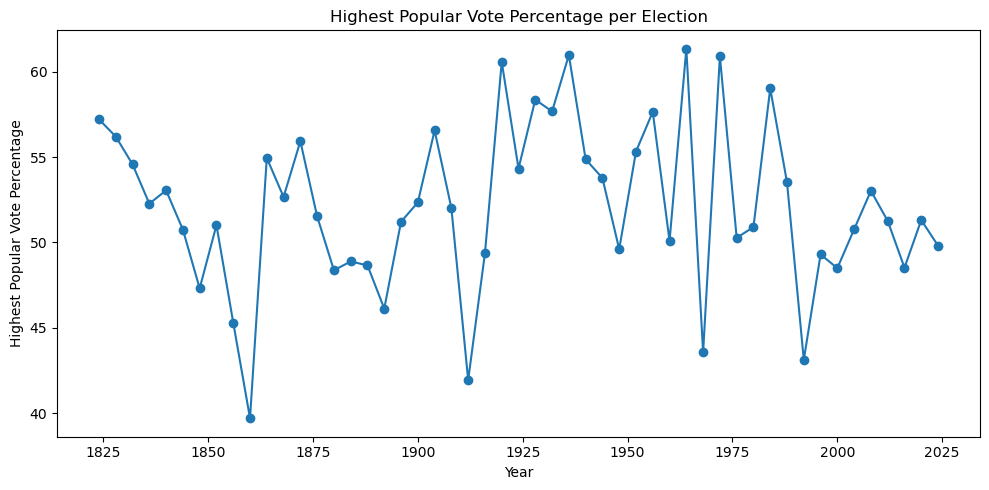

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(
    highest_percent_per_election["Year"],
    highest_percent_per_election["max_percent"],
    marker="o",
)
plt.title("Highest Popular Vote Percentage per Election")
plt.xlabel("Year")
plt.ylabel("Highest Popular Vote Percentage")
plt.tight_layout()
plt.show()


### 8. Candidates per Election Trend

What is the trend in the number of candidates per election?

#### (a) Analysis Plan

"For each unique value of `Year`, count the number of rows."

"Each row represents one candidate running in that election."

"Create a DataFrame with one row per election year and columns `Year` and `n_candidates`."

"Sort the DataFrame in increasing order of `Year`."

#### (b) Polars Code


In [28]:
candidates_per_election = (
    elections.group_by("Year")
    .agg(n_candidates=pl.len())
    .sort("Year")
)
candidates_per_election


Year,n_candidates
i64,u32
1824,2
1828,2
1832,3
1836,3
1840,2
…,…
2008,6
2012,4
2016,6


#### (c) SQL Query


In [29]:
%%sql --save query_q8
SELECT Year, COUNT(*) AS n_candidates
FROM elections
GROUP BY Year
ORDER BY Year;


Running query in 'duckdb:///:memory:'

Year,n_candidates
1824,2
1828,2
1832,3
1836,3
1840,2
1844,2
1848,3
1852,3
1856,3
1860,4


In [30]:
query = %sqlcmd snippets query_q8
res_q8 = conn.query(query).pl()
res_q8


Year,n_candidates
i64,i64
1824,2
1828,2
1832,3
1836,3
1840,2
…,…
2008,6
2012,4
2016,6


#### Visualization


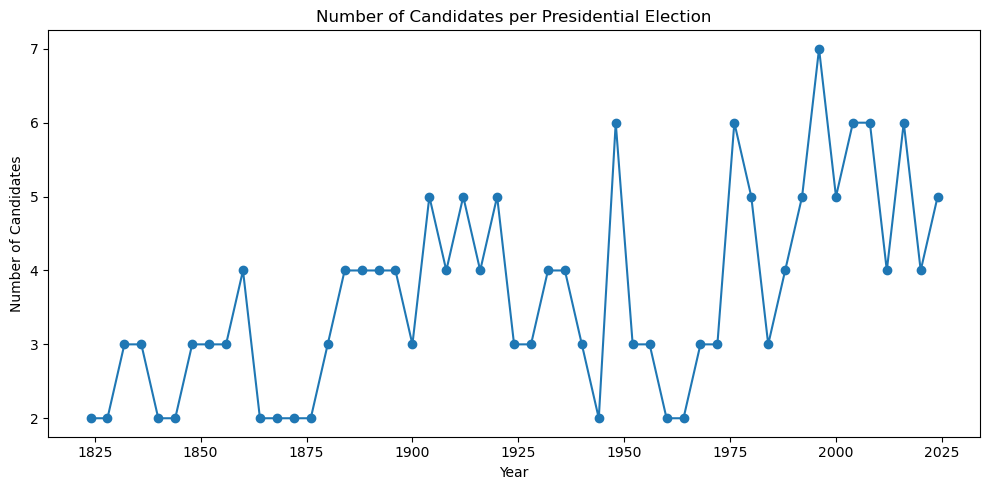

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(
    candidates_per_election["Year"],
    candidates_per_election["n_candidates"],
    marker="o",
)
plt.title("Number of Candidates per Presidential Election")
plt.xlabel("Year")
plt.ylabel("Number of Candidates")
plt.tight_layout()
plt.show()


### 9. Most Election Wins by Party

Which party has won the most elections?

#### (a) Analysis Plan

"For each row, keep only the rows where the candidate won the election."

"For each unique value of `Party` in the remaining data, count the number of rows."

"Sort the DataFrame in descending order of the number of wins."

The grouped count represents the total number of elections won by each party.

#### (b) Polars Code


In [32]:
wins_by_party = (
    elections.filter(pl.col("Result") == "win")
    .group_by("Party")
    .agg(n_wins=pl.len())
    .sort("n_wins", descending=True)
)
wins_by_party


Party,n_wins
str,u32
"""Republican""",24
"""Democratic""",23
"""Whig""",2
"""National Union""",1
"""Democratic-Republican""",1


#### (c) SQL Query


In [33]:
%%sql --save query_q9
SELECT Party, COUNT(*) AS n_wins
FROM elections
WHERE Result = 'win'
GROUP BY Party
ORDER BY n_wins DESC;


Running query in 'duckdb:///:memory:'

Party,n_wins
Republican,24
Democratic,23
Whig,2
Democratic-Republican,1
National Union,1


In [34]:
query = %sqlcmd snippets query_q9
res_q9 = conn.query(query).pl()
res_q9


Party,n_wins
str,i64
"""Republican""",24
"""Democratic""",23
"""Whig""",2
"""Democratic-Republican""",1
"""National Union""",1


#### Visualization


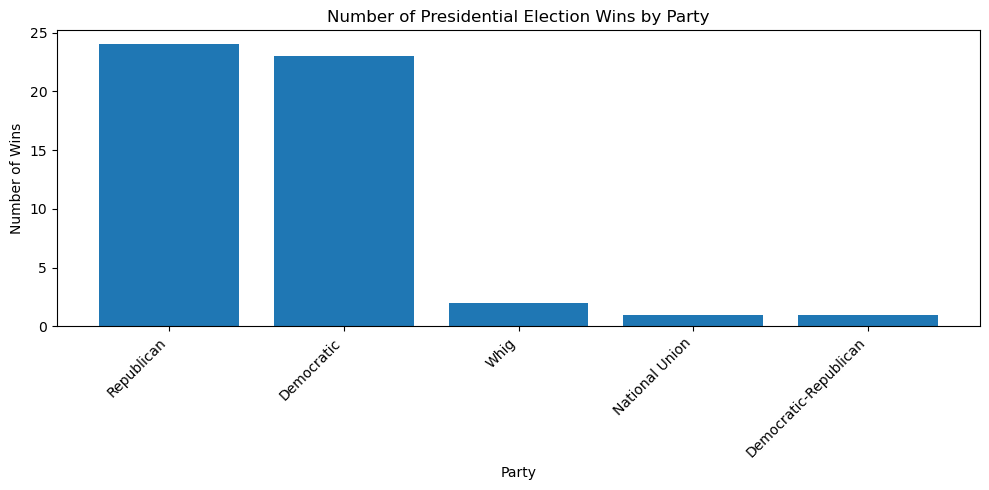

In [35]:
plt.figure(figsize=(10, 5))
plt.bar(wins_by_party["Party"], wins_by_party["n_wins"])
plt.title("Number of Presidential Election Wins by Party")
plt.xlabel("Party")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 10. Distribution of Winning Percentages

What does the distribution of winning percentages among all election winners look like?

#### (a) Analysis Plan

"For each row, keep only the rows where the candidate won the election."

"For each winning candidate, use the value in the `%` column."

"Create a DataFrame with one row per election winner and columns `Year`, `Candidate`, and `%`."

The histogram shows how common different winning popular vote percentages are among election winners.

#### (b) Polars Code


In [36]:
winning_percentages = (
    elections.filter(pl.col("Result") == "win")
    .select(["Year", "Candidate", "%"])
    .sort("Year")
)
winning_percentages


Year,Candidate,%
i64,str,f64
1824,"""John Quincy Adams""",42.789878
1828,"""Andrew Jackson""",56.203927
1832,"""Andrew Jackson""",54.574789
1836,"""Martin Van Buren""",52.272472
1840,"""William Henry Harrison""",53.051213
…,…,…
2008,"""Barack Obama""",53.02351
2012,"""Barack Obama""",51.258484
2016,"""Donald Trump""",46.407862


#### (c) SQL Query


In [37]:
%%sql --save query_q10
SELECT Year, Candidate, "%"
FROM elections
WHERE Result = 'win'
ORDER BY Year;


Running query in 'duckdb:///:memory:'

Year,Candidate,%
1824,John Quincy Adams,42.78987796
1828,Andrew Jackson,56.20392707
1832,Andrew Jackson,54.57478905
1836,Martin Van Buren,52.27247202
1840,William Henry Harrison,53.05121324
1844,James Polk,50.749477
1848,Zachary Taylor,47.30929648
1852,Franklin Pierce,51.01316828
1856,James Buchanan,45.30608033
1860,Abraham Lincoln,39.69940846


In [38]:
query = %sqlcmd snippets query_q10
res_q10 = conn.query(query).pl()
res_q10


Year,Candidate,%
i64,str,f64
1824,"""John Quincy Adams""",42.789878
1828,"""Andrew Jackson""",56.203927
1832,"""Andrew Jackson""",54.574789
1836,"""Martin Van Buren""",52.272472
1840,"""William Henry Harrison""",53.051213
…,…,…
2008,"""Barack Obama""",53.02351
2012,"""Barack Obama""",51.258484
2016,"""Donald Trump""",46.407862


#### Visualization


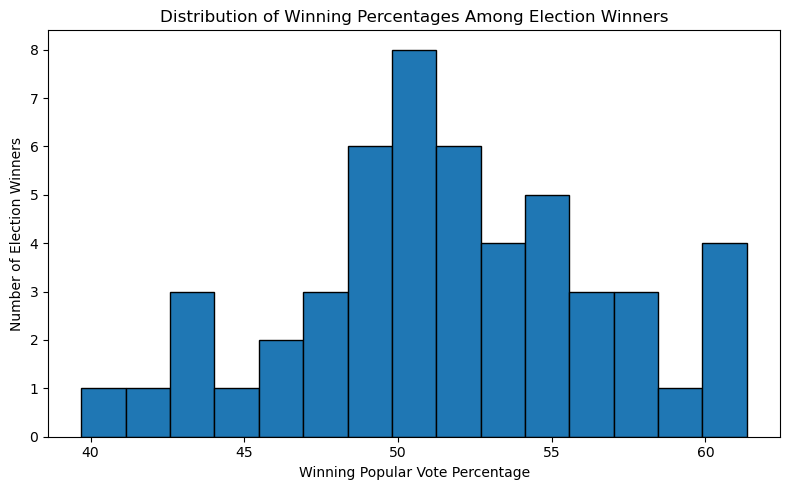

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(winning_percentages["%"], bins=15, edgecolor="black")
plt.title("Distribution of Winning Percentages Among Election Winners")
plt.xlabel("Winning Popular Vote Percentage")
plt.ylabel("Number of Election Winners")
plt.tight_layout()
plt.show()
